In [1]:
# ---
 # jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: hydrogen
#       format_version: '1.3'
#       jupytext_version: 1.18.1
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# HYRR Quickstart — p + Mo-100 → Tc-99m

This notebook demonstrates the full HYRR pipeline for the standard medical isotope production case:

- **Beam**: 16 MeV protons, 0.15 mA
- **Target**: Enriched Mo-100, exit energy 12 MeV
- **Irradiation**: 24 hours
- **Cooling**: 24 hours

We'll compute production rates, activities, depth profiles, and power density — all from first principles using PSTAR stopping powers and TENDL cross-sections.

## 1. Setup

In [2]:
%matplotlib inline

from hyrr import (
    Beam, Element, DataStore, Layer, TargetStack,
    compute_stack, result_summary, result_to_polars,
)
from hyrr.materials import resolve_element
from hyrr.plotting import (
    plot_activity_vs_time, plot_cooling_curve,
    plot_depth_profile, plot_purity_vs_cooling,
)

db = DataStore("../nucl-parquet")

## 2. Define beam and target

16 MeV proton beam at 0.15 mA on an enriched Mo-100 target. The target thickness is determined by the exit energy (12 MeV).

In [3]:
beam = Beam(projectile="p", energy_MeV=16.0, current_mA=0.15)

mo100 = resolve_element(db, "Mo", enrichment={100: 1.0})

target = Layer(
    density_g_cm3=10.22,
    elements=[(mo100, 1.0)],
    energy_out_MeV=12.0,
)

stack = TargetStack(
    beam=beam,
    layers=[target],
    irradiation_time_s=86400.0,   # 24 h
    cooling_time_s=86400.0,       # 24 h
    area_cm2=1.0,
)

print(f"Beam: {beam.projectile} at {beam.energy_MeV} MeV, {beam.current_mA} mA")
print(f"Particles/s: {beam.particles_per_second:.4E}")

Beam: p at 16.0 MeV, 0.15 mA
Particles/s: 9.3623E+14


## 3. Run the simulation

A single call computes everything: stopping powers, production rates, Bateman equations, depth profiles, and heat.

In [4]:
result = compute_stack(db, stack)

## 4. Text summary

In [5]:
print(result_summary(result))

HYRR — Hierarchical Yield and Radionuclide Rates

Projectile:         p
Beam energy:        16.000 MeV
Beam current:       0.150 mA
Irradiation time:   1d 0h 0m 0s
Cooling time:       1d 0h 0m 0s
Particles/s:        9.362264E+14

--- Layer 1 ---
  E_in:      16.000 MeV
  E_out:     12.000 MeV
  dE:        4.000 MeV
  Heat:      0.599 kW
  Stopping:  PSTAR

  Isotope      Source     Prod. rate [1/s]   Activity [GBq]   Yield [GBq/mAh]            Half-life
  -----------------------------------------------------------------------------------------------
  Tc-99m       both           2.766553E+11       2.1063E+01      5.850789E+00                6.0 h
                                   direct:       1.6280E+01
                                 ingrowth:       4.7826E+00
  Mo-99        both           2.940016E+10       5.0938E+00      1.414941E+00                2.7 d
                                   direct:       5.0938E+00
                                 ingrowth:       0.0000E+00
  Nb-9

## 5. DataFrame view

In [6]:
df = result_to_polars(result)
df.sort("activity_Bq", descending=True).head(15)

layer_index,isotope,Z,A,state,half_life_s,production_rate,activity_Bq,saturation_yield_Bq_uA,energy_in_MeV,energy_out_MeV,delta_E_MeV,heat_kW,stopping_power_source,source,activity_direct_Bq,activity_ingrowth_Bq
i64,str,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64
0,"""Tc-99m""",43,99,"""m""",21636.0,2.7666e11,2.1063e10,1.8444e9,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",1.6280e10,4.7826e9
0,"""Mo-99""",42,99,"""""",237384.0,2.9400e10,5.0938e9,1.9600e8,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",5.0938e9,0.0
0,"""Nb-96""",41,96,"""""",84060.0,3.7762e8,9.4371e7,2.5175e6,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",9.4371e7,0.0
0,"""Tc-99""",43,99,"""""",6.7532e12,9.9046e11,11251.050157,6.6031e9,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",8783.544151,2467.506007
0,"""Nb-97""",41,97,"""""",4326.0,5.1714e9,5991.739192,3.4476e7,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",5027.52437,964.214822
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,"""Zr-93""",40,93,"""""",4.8282e13,0.0,1.0018e-9,0.0,16.0,12.0,4.0,0.599374,"""PSTAR""","""daughter""",0.0,1.0018e-9
0,"""Nb-98m""",41,98,"""m""",3078.0,0.215213,7.6367e-10,0.001435,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",7.6367e-10,0.0
0,"""Y-92""",39,92,"""""",12744.0,1.0699e-8,9.6494e-11,7.1328e-11,16.0,12.0,4.0,0.599374,"""PSTAR""","""both""",9.6494e-11,0.0


## 6. Activity vs time

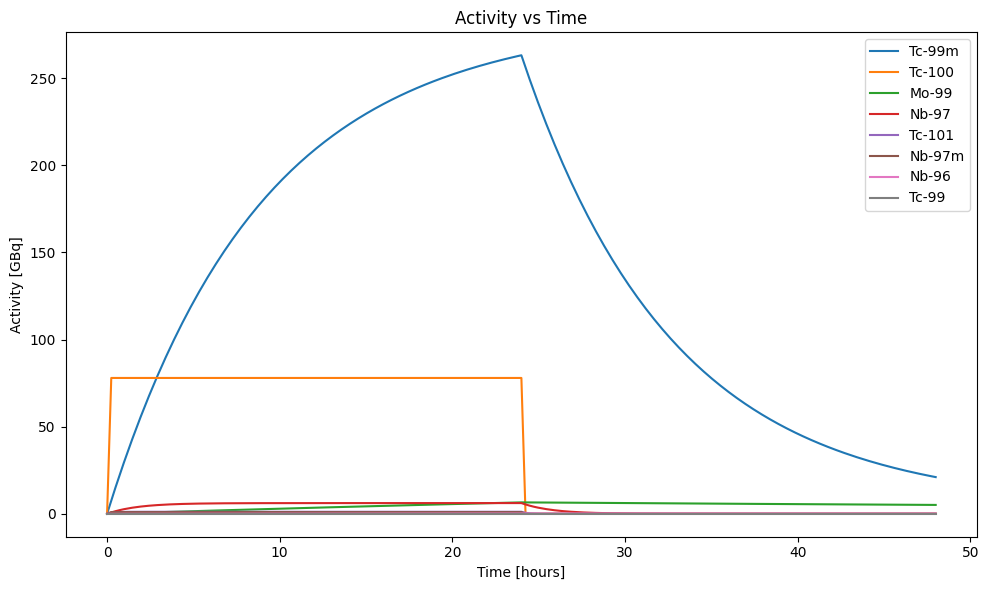

In [7]:
lr = result.layer_results[0]
plot_activity_vs_time(lr.isotope_results, top_n=8)

## 7. Cooling curve

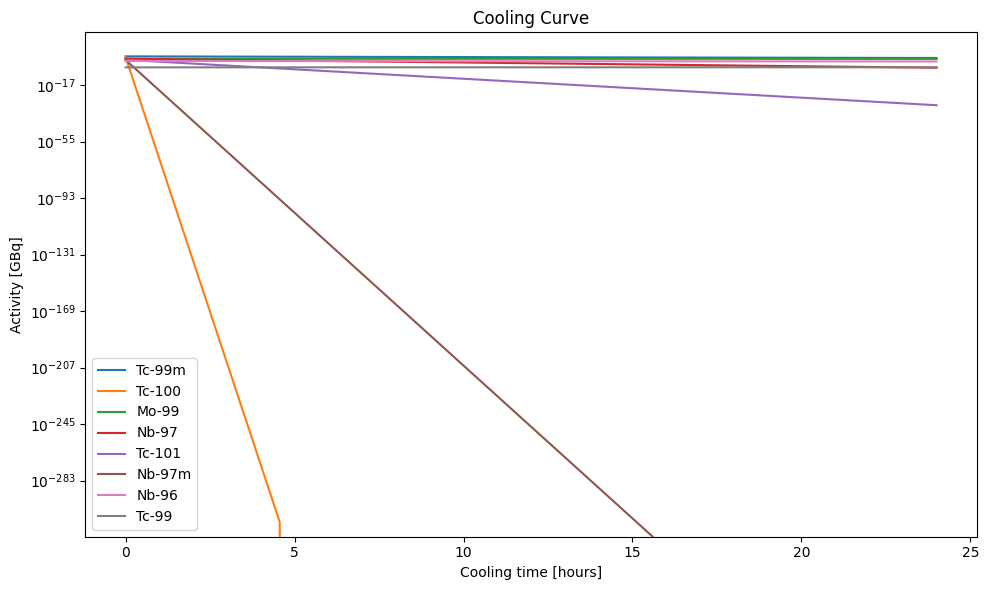

In [8]:
plot_cooling_curve(
    lr.isotope_results,
    irradiation_time_s=stack.irradiation_time_s,
    top_n=8,
)

## 8. Power density depth profile

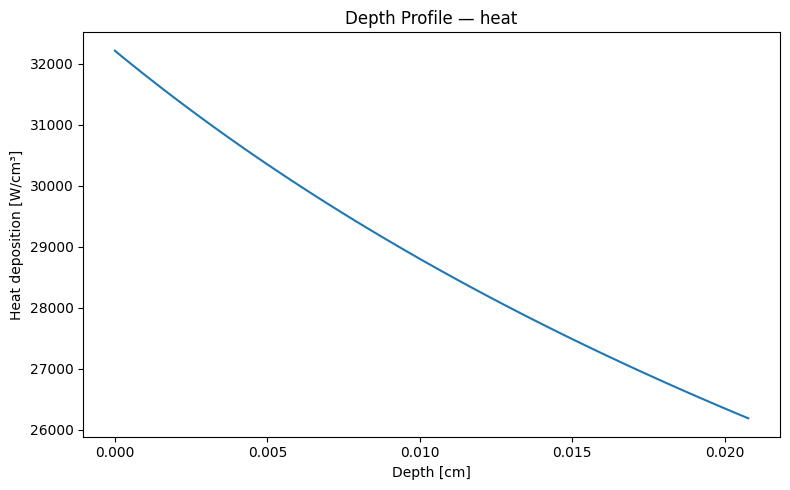

In [9]:
plot_depth_profile(lr, quantity="heat")

## 9. Radionuclidic purity

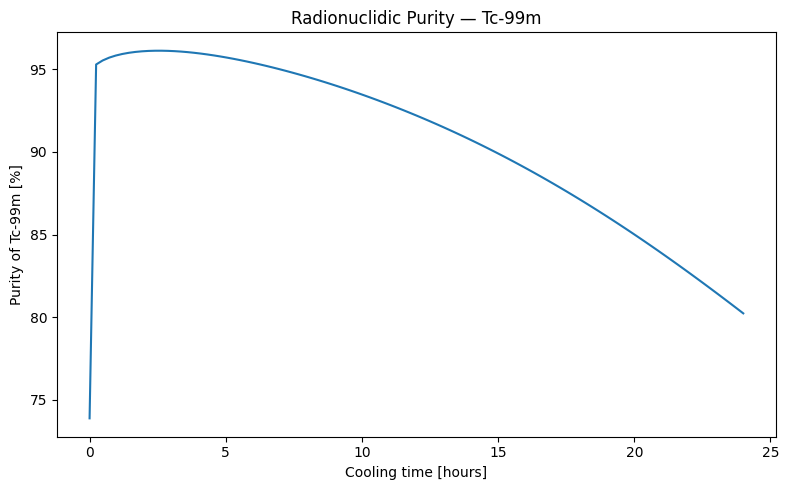

In [10]:
plot_purity_vs_cooling(
    lr.isotope_results,
    target_isotope="Tc-99m",
    irradiation_time_s=stack.irradiation_time_s,
)

## 10. Stopping power sources

Shows which data source (PSTAR, ASTAR, or pycatima/SRIM fallback) was used for each element's stopping power.

In [11]:
for Z, source in lr.stopping_power_sources.items():
    symbol = db.get_element_symbol(Z)
    print(f"  {symbol} (Z={Z}): {source}")

  Mo (Z=42): PSTAR
